<a href="https://colab.research.google.com/github/lifvl/python-sdaia-aai/blob/main/ex1_reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M1.Ex1: Model Hours vs Marks

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex1_reg.ipynb)
- Raw Dataset: [Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv)

In [3]:
import pandas as pd
import sklearn

### Step 1. Load the data

In [15]:
url = "https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv"
df = pd.read_csv(url)

### Step 2.a Assign variables `X` to the features and `y` to the target

In [17]:
X = df[['Hours_Studied']] 
y = df['Marks']        
df   

,Hours_Studied,Marks
0,4.76,46.27
1,3.00,34.30
2,2.08,33.63
3,4.04,47.81
4,9.49,66.26
...,...,...
95,3.20,28.66
96,9.76,70.27
97,4.54,43.99
98,9.03,65.17


### Step 2.b print the type of each

In [18]:
print(f"Type of X: {type(X)}")
print(f"Type of y: {type(y)}")

Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [19]:
if df['Marks'].dtype in ['int64', 'float64']:
    target_type = "Numerical"
    task = "Regression"
else:
    target_type = "Categorical"
    task = "Classification"

print(f"Target is: {target_type}")
print(f"The task is: {task}")

Target is: Numerical
The task is: Regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [20]:
print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")

Shape of X (features): (100, 1)
Shape of y (target): (100,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [21]:
summary = df.describe()
print(summary)

print("\nMedian of the data:")
print(df.median())

       Hours_Studied       Marks
count     100.000000  100.000000
mean        5.376300   46.360200
std         2.593013   14.284805
min         1.050000   20.190000
25%         3.175000   33.675000
50%         5.565000   47.485000
75%         7.255000   57.377500
max         9.870000   73.260000

Median of the data:
Hours_Studied     5.565
Marks            47.485
dtype: float64


### Step 5. Plot the feature vs the target

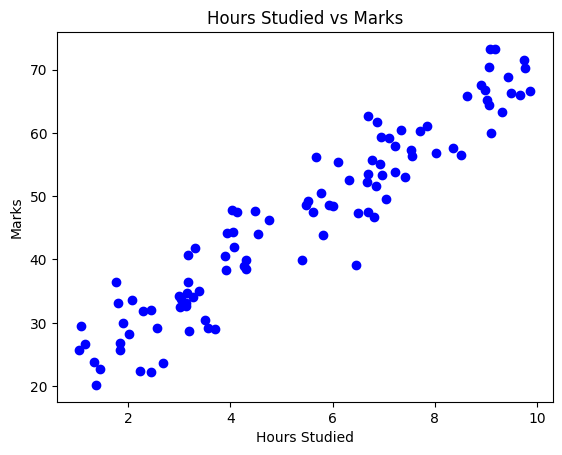

In [22]:
import matplotlib.pyplot as plt

plt.scatter(X, y, color='blue')
plt.title('Hours Studied vs Marks')
plt.xlabel('Hours Studied')
plt.ylabel('Marks')
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [ ]:
increasing 

### Step 7. Initialize a `LinearRegression` model

In [23]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 80
Testing samples: 20


### Step 9.a Train the model on the training set

In [25]:
model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


### Step 9.b Identify the learned slope and the y-intercept of the model

In [26]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (Coefficient): {slope:.4f}")
print(f"Y-intercept: {intercept:.4f}")

Slope (Coefficient): 5.1644
Y-intercept: 18.5386


### Step 9.c how much marks do we get per 1 hour of study?

In [27]:
print(f"We get approximately {slope:.2f} marks per 1 hour of study.")

We get approximately 5.16 marks per 1 hour of study.


### Step 9.d how much does a 10 minutes increase of study time adds to our marks?

In [28]:
ten_min_increase = slope * (10 / 60)
print(f"A 10-minute increase adds approximately {ten_min_increase:.2f} marks.")

A 10-minute increase adds approximately 0.86 marks.


### Step 9.e if one doesn't study at all, how much marks do they get?

In [29]:
print(f"If a student studies 0 hours, they are expected to get {intercept:.2f} marks.")

If a student studies 0 hours, they are expected to get 18.54 marks.


### Step 10. Evaluate the model on the test set

In [30]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.4f}") 

Mean Squared Error: 14.73
R-squared Score: 0.9258


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [31]:
sample_X = X_test.head(3)
sample_y_true = y_test.head(3)

sample_y_pred = model.predict(sample_X)

comparison = pd.DataFrame({
    'Hours Studied': sample_X.values.flatten(),
    'Actual Marks': sample_y_true.values,
    'Predicted Marks': sample_y_pred
})

print(comparison)

   Hours Studied  Actual Marks  Predicted Marks
0           3.02         32.50        34.135183
1           8.90         67.54        64.502080
2           6.78         55.70        53.553471


### Step 12. Plot the data and the regression line

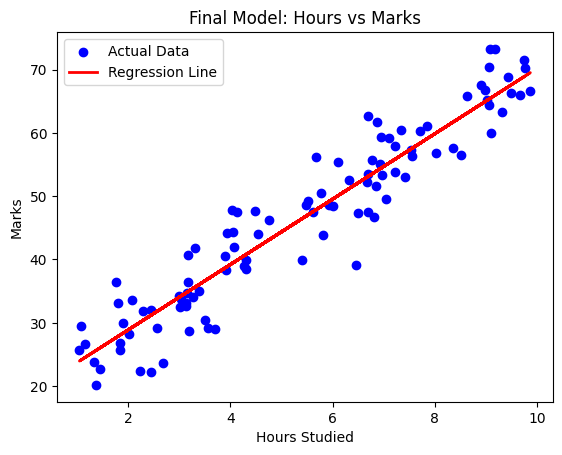

In [32]:
import matplotlib.pyplot as plt

plt.scatter(X, y, color='blue', label='Actual Data')

plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')

plt.title('Final Model: Hours vs Marks')
plt.xlabel('Hours Studied')
plt.ylabel('Marks')
plt.legend()
plt.show()